# Machin!!


In [62]:
import scanpy as sc
import os
import matplotlib.pyplot as plt

In [63]:
# Load as cells x genes (transpose because genes are rows in gut.tsv)
data = sc.read_text(os.getcwd() + "\\gut.tsv", delimiter="\t").T
data.var_names_make_unique()

In [64]:

n_cells_1 = data.n_obs
n_genes_1 = data.n_vars

In [65]:
#filters
sc.pp.filter_cells(data, min_genes=200) # filter low-quality cells
sc.pp.filter_genes(data, min_cells=10)  # filter rare genes

In [66]:
n_cells_2 = data.n_obs
n_genes_2 = data.n_vars
print(f"number of cells removed:{n_cells_1 - n_cells_2}")
print(f"number of genes removed:{n_genes_1 - n_genes_2}")

number of cells removed:0
number of genes removed:1817


In [67]:
sc.pp.calculate_qc_metrics(data, inplace=True)
n_cells_by_counts = data.var.n_cells_by_counts
mean_counts = data.var.mean_counts
total_counts = data.obs.total_counts

In [68]:
print(n_cells_by_counts)

128up                   123
14-3-3epsilon          3064
14-3-3zeta             4622
140up                    92
18SrRNA-Psi:CR41602    1062
                       ... 
zip                    3531
zld                      22
zormin                 1479
zyd                      77
zye                      95
Name: n_cells_by_counts, Length: 10113, dtype: int64


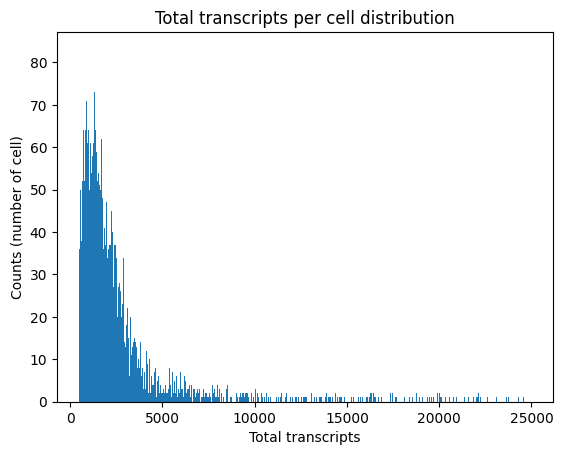

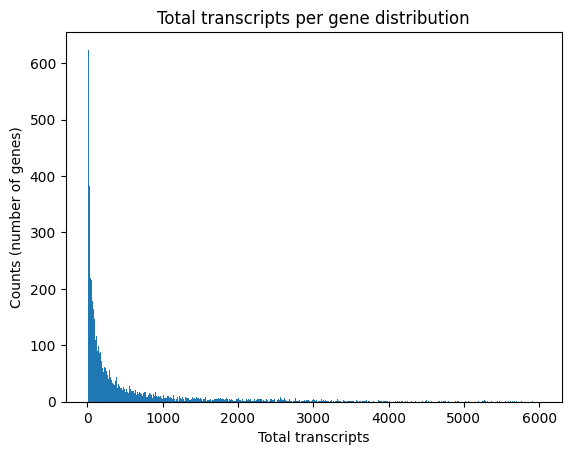

In [69]:
plt.hist(total_counts,bins = 1000)
plt.title("Total transcripts per cell distribution")
plt.xlabel("Total transcripts")
plt.ylabel("Counts (number of cell)")
plt.show()
plt.hist(n_cells_by_counts,bins = 1000)
plt.title("Total transcripts per gene distribution")
plt.xlabel("Total transcripts")
plt.ylabel("Counts (number of genes)")
plt.show()


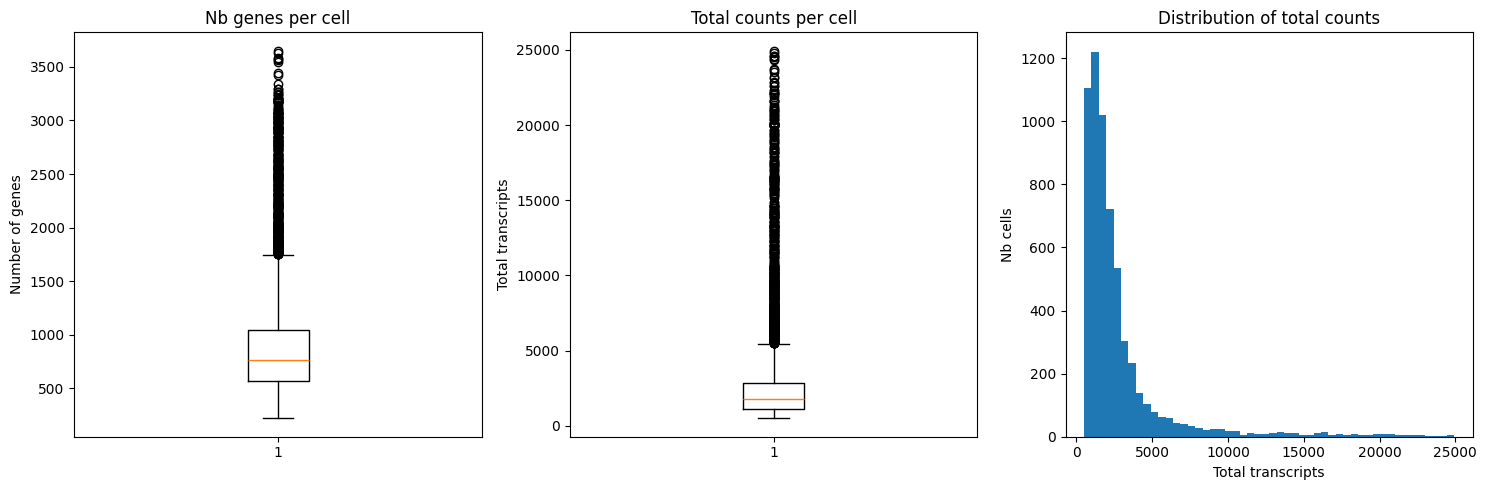

In [70]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Boxplot of nb genes expressed per cell
axes[0].boxplot(data.obs.n_genes_by_counts)
axes[0].set_title("Nb genes per cell")
axes[0].set_ylabel("Number of genes")

# 2. Boxplot of total counts (transcripts) per cell
axes[1].boxplot(data.obs.total_counts)
axes[1].set_title("Total counts per cell")
axes[1].set_ylabel("Total transcripts")

# 3. Histogram of total counts
axes[2].hist(data.obs.total_counts, bins=50)
axes[2].set_title("Distribution of total counts")
axes[2].set_xlabel("Total transcripts")
axes[2].set_ylabel("Nb cells")

plt.tight_layout()
plt.show()

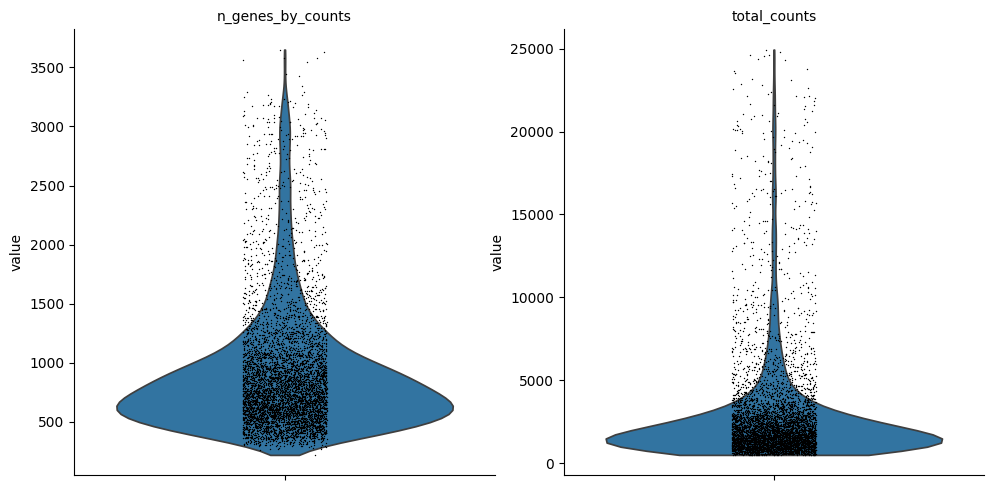

In [71]:
sc.pl.violin(data, ["n_genes_by_counts", "total_counts"], multi_panel=True)

In [72]:
#normalizing the data 
sc.pp.normalize_total(data,target_sum=10000)
sc.pp.log1p(data)

In [73]:
data.raw = data.copy()   # to then normalize and scale data for PCA/clustering

sc.pp.highly_variable_genes(data, n_top_genes=2000)
data = data[:, data.var.highly_variable]
sc.pp.scale(data, max_value=10)

C:\Users\matte\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


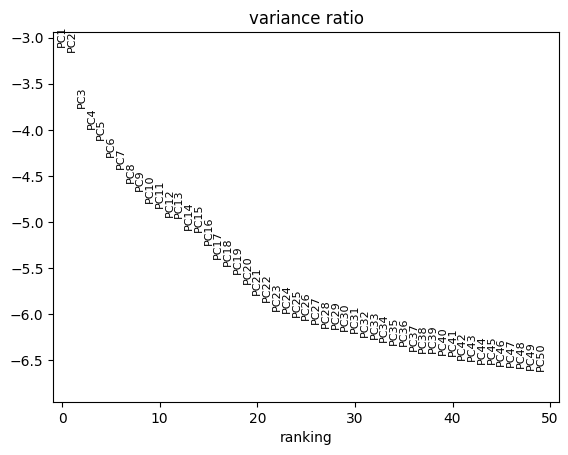

In [74]:
sc.tl.pca(data)
sc.pl.pca_variance_ratio(data, n_pcs=50, log=True)
sc.pp.neighbors(data, n_pcs=30)

In [75]:
sc.tl.leiden(data,resolution=0.1)

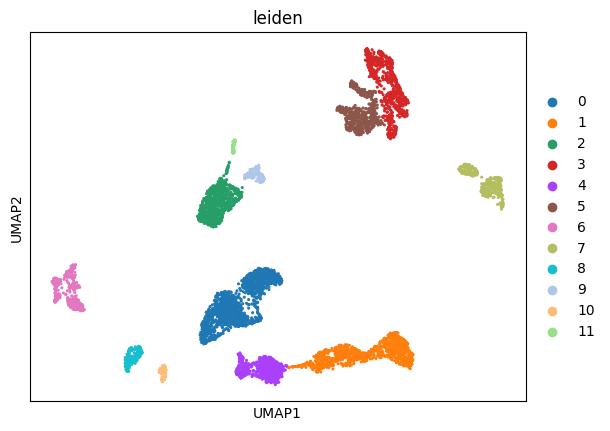

In [76]:
#t-sne
sc.tl.umap(data)
#visulisation
sc.pl.umap(data,color = "leiden")

In [77]:
sc.tl.rank_genes_groups(data, groupby="leiden",method = "wilcoxon",n_genes=3)

In [78]:
result = sc.get.rank_genes_groups_df(data,group = None)
clusters = result["group"].unique()
top_genes = []
for c in clusters:
    top_genes.append(result[result["group"] == c].sort_values(by = "logfoldchanges",ascending = False)["names"].iloc[0])

In [79]:
print(result)

   group        names     scores  logfoldchanges          pvals      pvals_adj
0      0       CG5065  50.296288        6.796512   0.000000e+00   0.000000e+00
1      0      CG32694  49.317547        5.557981   0.000000e+00   0.000000e+00
2      0          rut  48.754192        5.107575   0.000000e+00   0.000000e+00
3      1          ple  45.006325        6.732787   0.000000e+00   0.000000e+00
4      1         retn  42.451401        4.623999   0.000000e+00   0.000000e+00
5      1           to  40.984245        6.278464   0.000000e+00   0.000000e+00
6      2      CG34220  43.874508       12.103208   0.000000e+00   0.000000e+00
7      2      CG34324  43.817547       12.496949   0.000000e+00   0.000000e+00
8      2       Muc68D  43.760246       14.200249   0.000000e+00   0.000000e+00
9      3          peb  31.167366        4.928308  2.950773e-213  9.947054e-210
10     3      CG43349  27.152590        5.798883  2.359847e-162  3.409304e-159
11     3          cib  26.487026        3.704796  1.

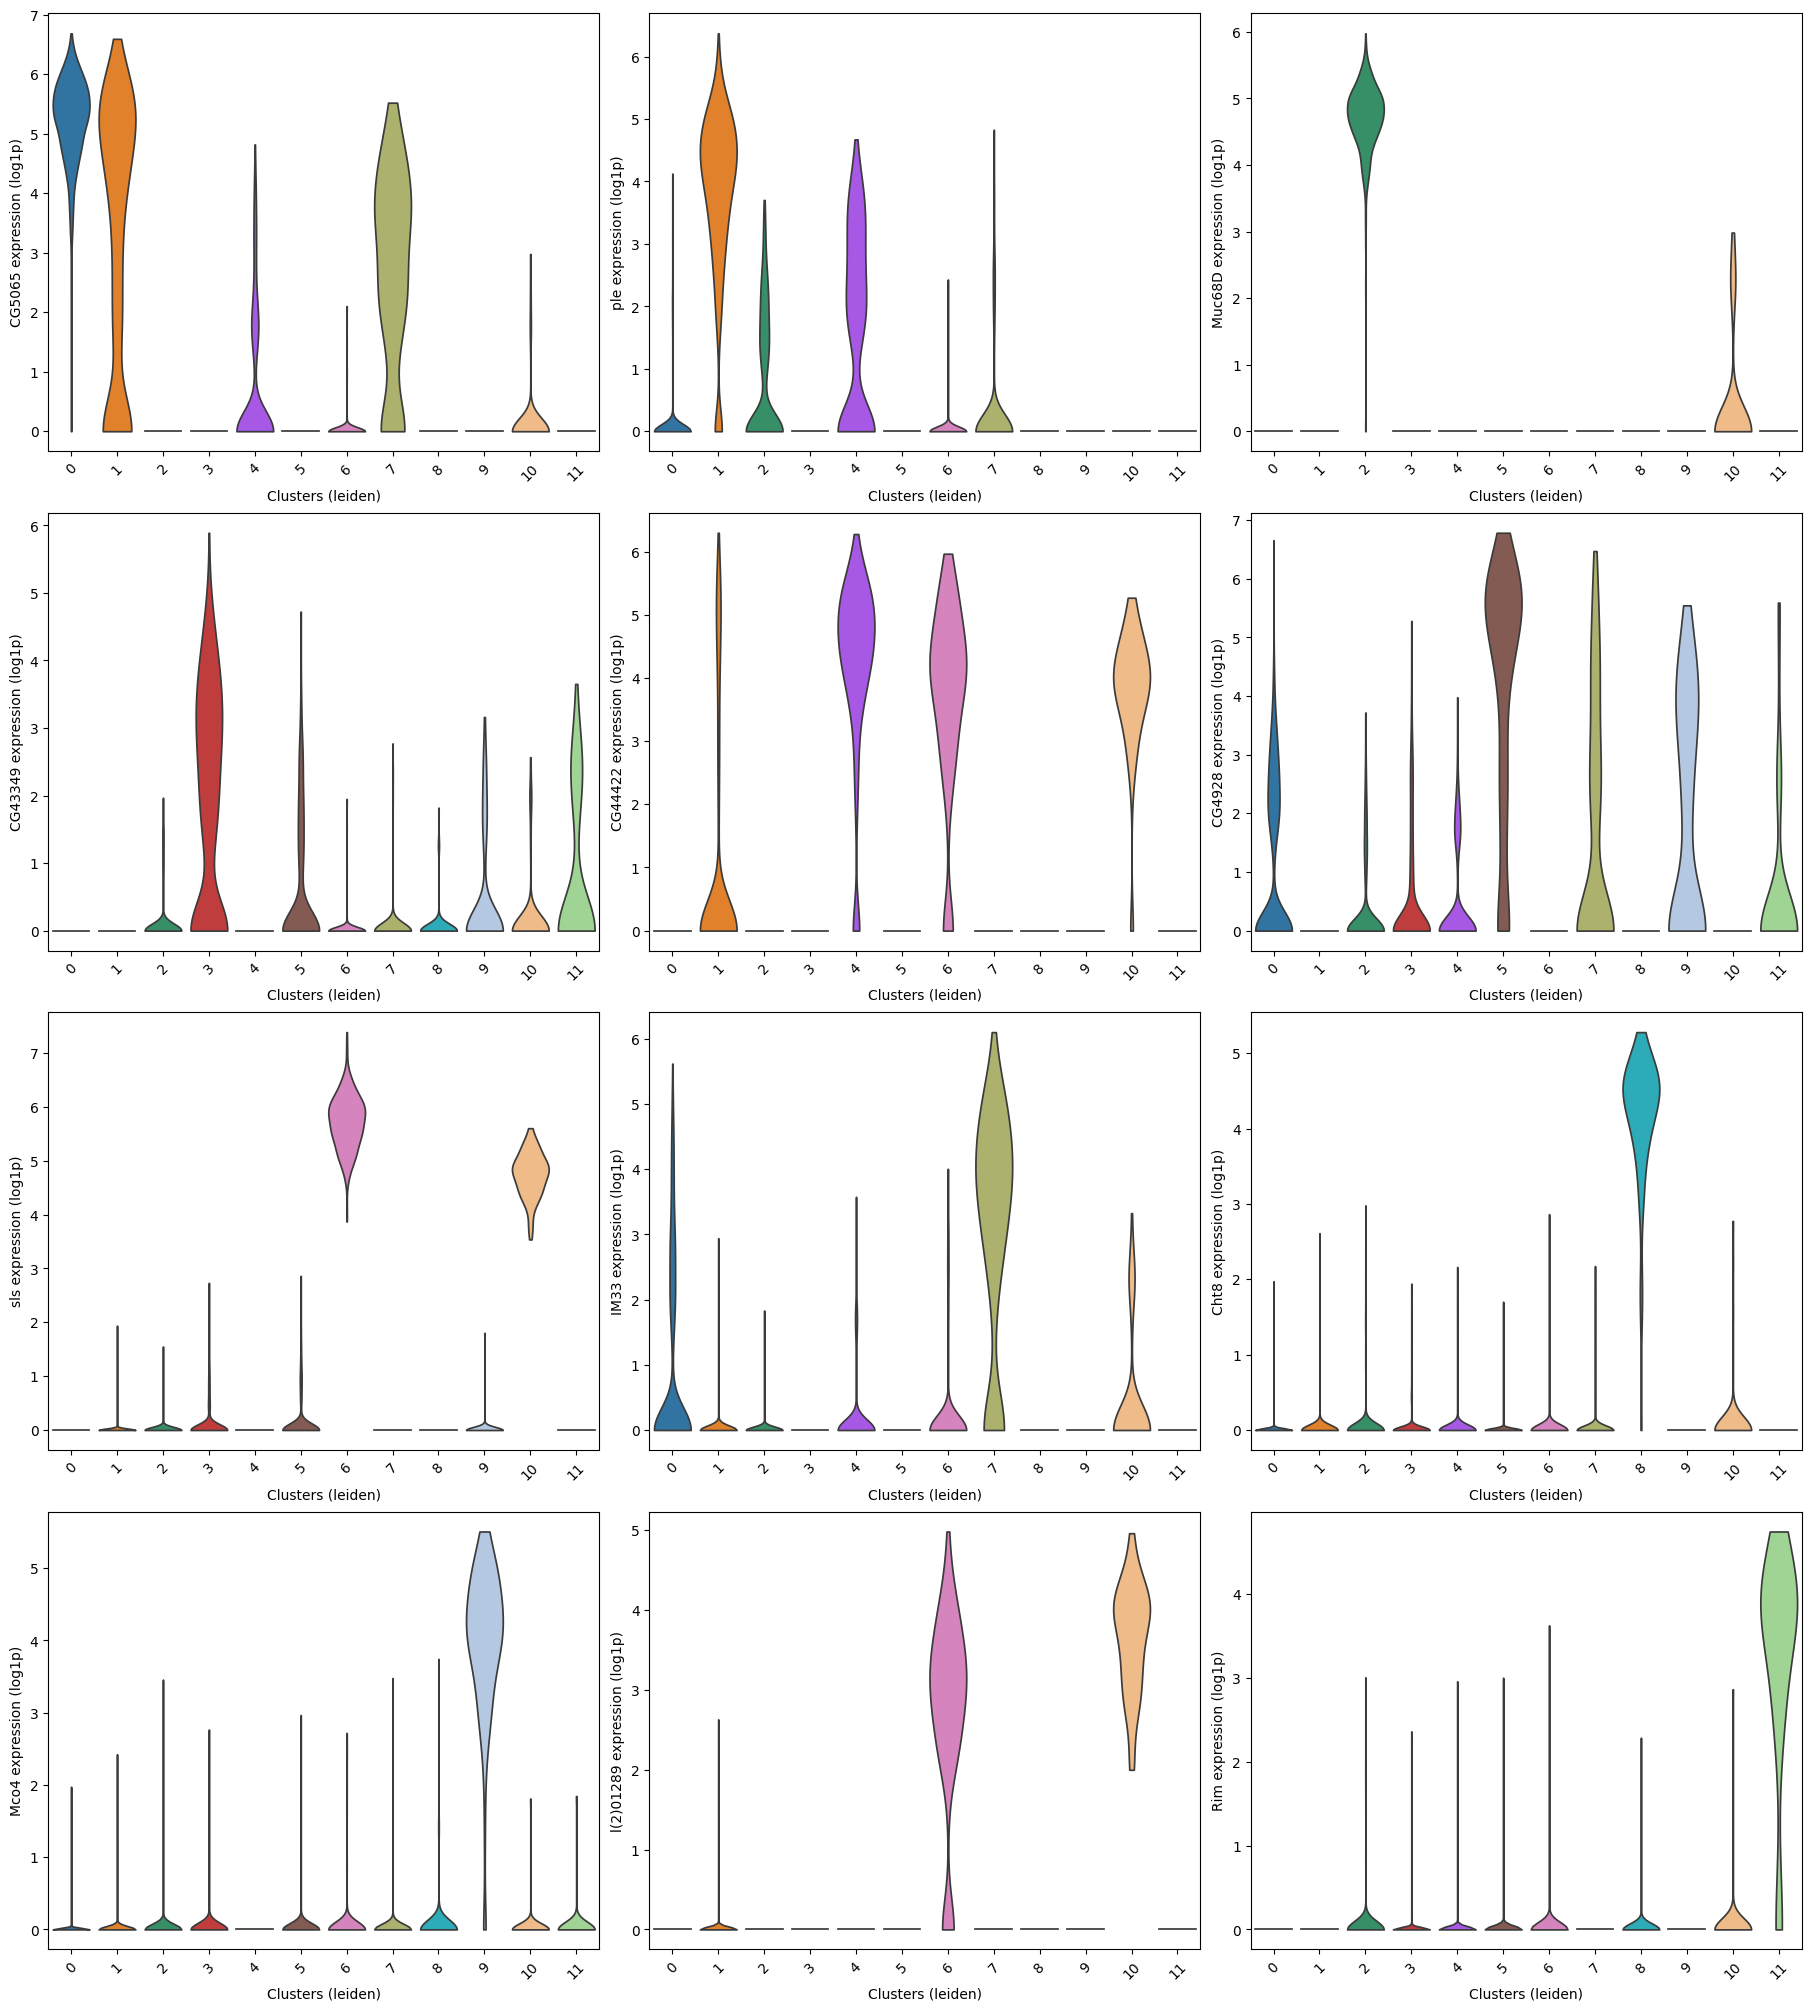

In [80]:
ncols = 3
nrows = (len(top_genes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, gene in enumerate(top_genes):
    sc.pl.violin(
        data,
        keys=gene,
        groupby="leiden",
        ax=axes[i],
        show=False,
        stripplot=False,
        rotation=45,
        use_raw=True
    )
    axes[i].set_ylabel(f"{gene} expression (log1p)")
    axes[i].set_xlabel("Clusters (leiden)")

for j in range(len(top_genes), len(axes)):
    axes[j].axis("off")

plt.show()

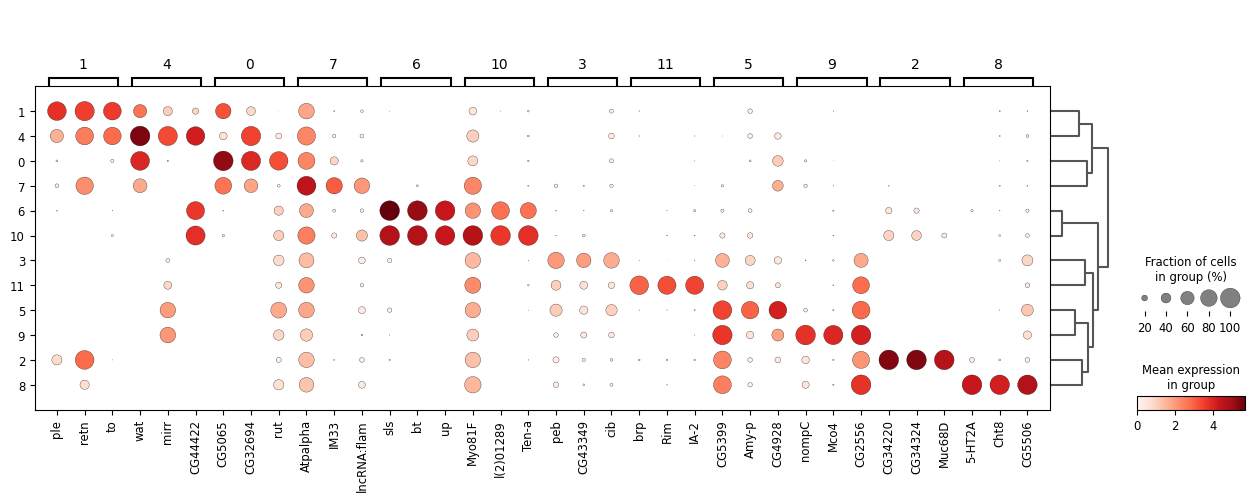

In [81]:
sc.pl.rank_genes_groups_dotplot(data, n_genes=5, use_raw=True)

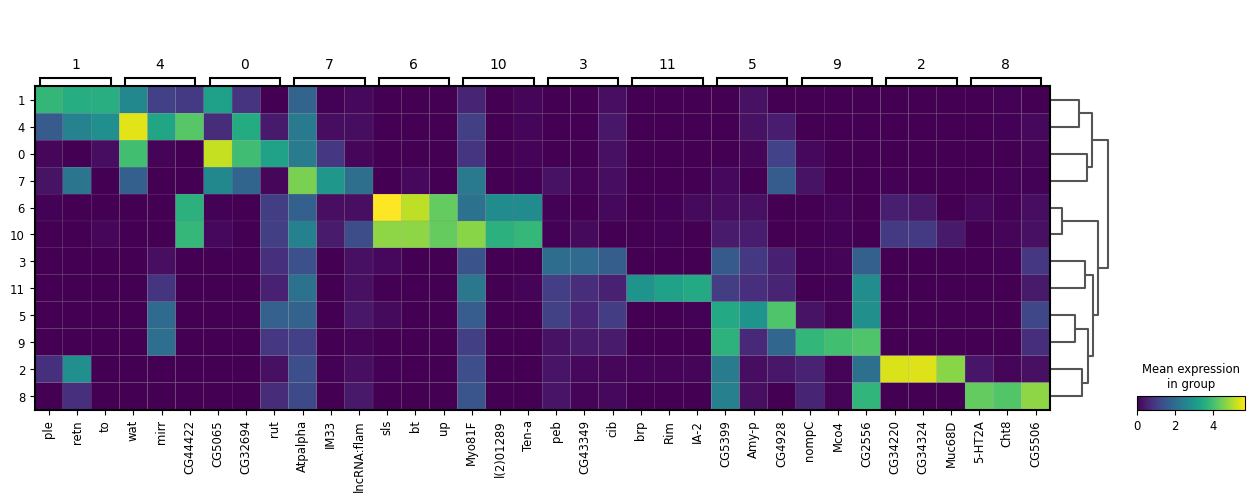

In [85]:
sc.pl.rank_genes_groups_matrixplot(data, n_genes=5, use_raw=True)

After this clustering, we can observe 12 different kinds of cells :

Clusters 1, 4, 0, 7 — Enterocytes (ECs)

Markers: to, wat, CG32694, Atpalpha

Description: Major absorptive epithelial cells involved in digestion, metabolism, and ion transport. Multiple clusters indicate regional and functional heterogeneity.

Clusters 6, 10 — Visceral muscle cells

Markers: sls, bt, Myo81F

Description: Contractile cells surrounding the gut, responsible for peristalsis.

Cluster 3 — Enteroblasts (EBs)

Markers: peb

Description: Non-dividing progenitor cells that differentiate into enterocytes or enteroendocrine cells.

Clusters 11, 5, 9 — Enteroendocrine cells (EEs)

Markers: IA-2, Rim, brp

Description: Hormone-secreting cells regulating digestion and systemic metabolism; multiple clusters suggest distinct EE subtypes.

Cluster 2 — Secretory epithelial cells

Markers: Muc68D

Description: Likely involved in mucus production and gut barrier function.

Cluster 8 — Barrier / specialized epithelial cells

Markers: Cht8, 5-HT2A

Description: Cells contributing to gut lining integrity and possibly involved in environmental sensing/signaling.

